/tmp/ipykernel_1052/2976995161.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2024-01-01', periods=24, freq='M')


Sample data ban gaya!
R2 Score: 0.9581774100874876
MAE: 2124.7528504359507


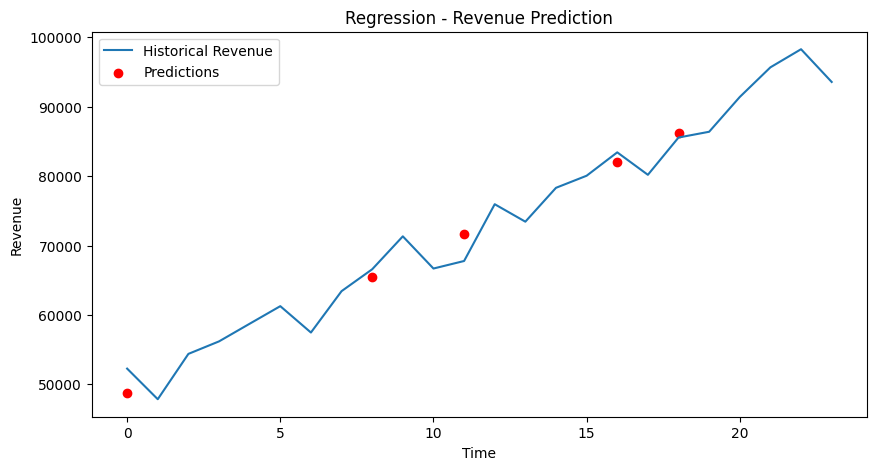

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# STEP 1: Sample Cleaned Sales Data banao
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', periods=24, freq='M')
revenue = [50000 + i*2000 + np.random.randint(-5000, 5000) for i in range(24)]

df = pd.DataFrame({
    'Date': dates,
    'Revenue': revenue,
    'Profit': [r*0.2 for r in revenue],
    'Region': np.random.choice(['North','South','East','West'], 24),
    'Department': np.random.choice(['Cloud Tech','Strategy'], 24)
})
df.to_excel('Cleaned_Sales_Data.xlsx', index=False)
print("Sample data ban gaya!")

# STEP 2: Predictive Analytics - Regression
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
monthly = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly['Time'] = range(len(monthly))
X = monthly[['Time']]
y = monthly['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

# STEP 3: Visualize
plt.figure(figsize=(10,5))
plt.plot(monthly['Time'], y, label='Historical Revenue')
plt.scatter(X_test['Time'], pred, color='red', label='Predictions')
plt.title('Regression - Revenue Prediction')
plt.xlabel('Time')
plt.ylabel('Revenue')
plt.legend()
plt.savefig('regression.png')
plt.show()

In [2]:
from google.colab import files
files.download('regression.png')
files.download('Cleaned_Sales_Data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>